# **Lifestyle Exploration and Analysis**
### **Overview**
This section examines five key behavioral variables: smoking status, e-cigarette usage, alcohol consumption, physical activity, and sleep hours. We explore how each factor individually, and in combination, relates to health disease.

**Questions we want to answer:**

1. How do the various lifestyle/behavioral factors relate to heart disease?

2. Among people who have heart disease, how prevalent is each behavioral/lifestyle factor?

3. How does sleep play a factor in heart disease?

4. Which states have the highest heart disease rates, and do lifestyle behaviors vary by region?

## Import Statements

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/data/heart_cleaned.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Helper Functions and Utilites

In [131]:
# Helper functions and utilities

# Helper for calculating heart disease rate for a given column
def heart_disease_rate(group_col, df):
    return df.groupby(group_col)['HadHeartDisease'].mean().mul(100).reset_index()

## **Q1: Behaviral Factors and Heart Disease**
---

**Question:** How do the various lifestyle/behavioral factors relate to heart disease?

### **Code & Visualizations**

In [132]:
# Columns of the lifestyle factors we are considering
lifestyle_cols = ['SmokerStatus', 'ECigaretteUsage', 'AlcoholDrinkers',
                  'PhysicalActivities', 'SleepHours', 'HadHeartDisease']
lifestyle_df = data[lifestyle_cols].copy()

# Dropping the rows that have unknowns in them for some of the columns
for col in ['SmokerStatus', 'ECigaretteUsage', 'AlcoholDrinkers', 'PhysicalActivities']:
    lifestyle_df = lifestyle_df[lifestyle_df[col] != 'Unknown']

# Distribution of each behavioral factor
factors = ['SmokerStatus', 'ECigaretteUsage', 'AlcoholDrinkers', 'PhysicalActivities']

for col in factors:
    display(lifestyle_df[col].value_counts(normalize=True).mul(100).round(2).to_frame('Percentage (%)'))

,Percentage (%)
SmokerStatus,
Never smoked,60.55
Former smoker,27.57
Current smoker - now smokes every day,8.58
Current smoker - now smokes some days,3.30


,Percentage (%)
ECigaretteUsage,
Never used e-cigarettes in my entire life,76.47
Not at all (right now),18.18
Use them some days,2.83
Use them every day,2.52


,Percentage (%)
AlcoholDrinkers,
Yes,53.22
No,46.78


,Percentage (%)
PhysicalActivities,
Yes,76.49
No,23.51


In [133]:
# Maps to make the labels shorter
smoker_labels = {
    'Current smoker - now smokes every day': 'Daily',
    'Current smoker - now smokes some days': 'Some Days',
    'Former smoker': 'Former',
    'Never smoked': 'Never',
}

ecig_labels = {
    'Never used e-cigarettes in my entire life': 'Never',
    'Not at all (right now)': 'Former',
    'Use them some days': 'Some Days',
    'Use them every day': 'Daily',
}

lifestyle_df['SmokerLabel'] = lifestyle_df['SmokerStatus'].map(smoker_labels)
lifestyle_df['ECigLabel'] = lifestyle_df['ECigaretteUsage'].map(ecig_labels)

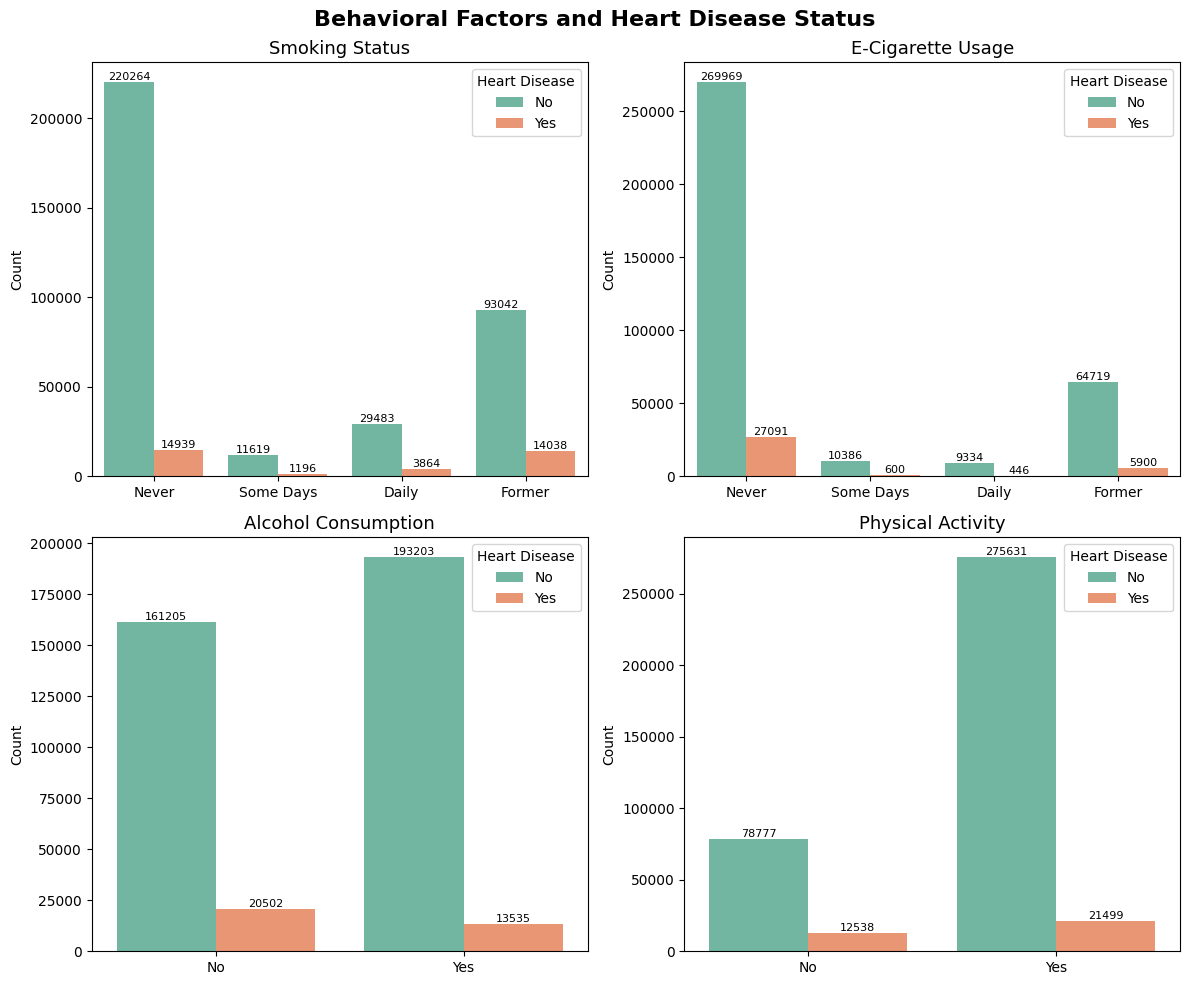

In [134]:
# Orders for the smoking and e-cig factors
smoker_order = ['Never', 'Some Days', 'Daily', 'Former']
ecig_order = ['Never', 'Some Days', 'Daily', 'Former']

# Suplots for the factors
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Behavioral Factors and Heart Disease Status', fontsize=16, fontweight='bold')


panels = [
    ('SmokerLabel',        'Smoking Status',      axes[0, 0], smoker_order),
    ('ECigLabel',          'E-Cigarette Usage',   axes[0, 1], ecig_order),
    ('AlcoholDrinkers',    'Alcohol Consumption', axes[1, 0], None),
    ('PhysicalActivities', 'Physical Activity',   axes[1, 1], None)
]

for col, title, ax, order in panels:

    # Count plot for each subplot
    sns.countplot(data=lifestyle_df, x=col, hue='HadHeartDisease',
                  order=order, ax=ax, palette='Set2')

    # Labels
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title='Heart Disease', labels=['No', 'Yes'])
    for c in ax.containers:
        ax.bar_label(c, fmt='%d', fontsize=8)

plt.tight_layout()

plt.show()

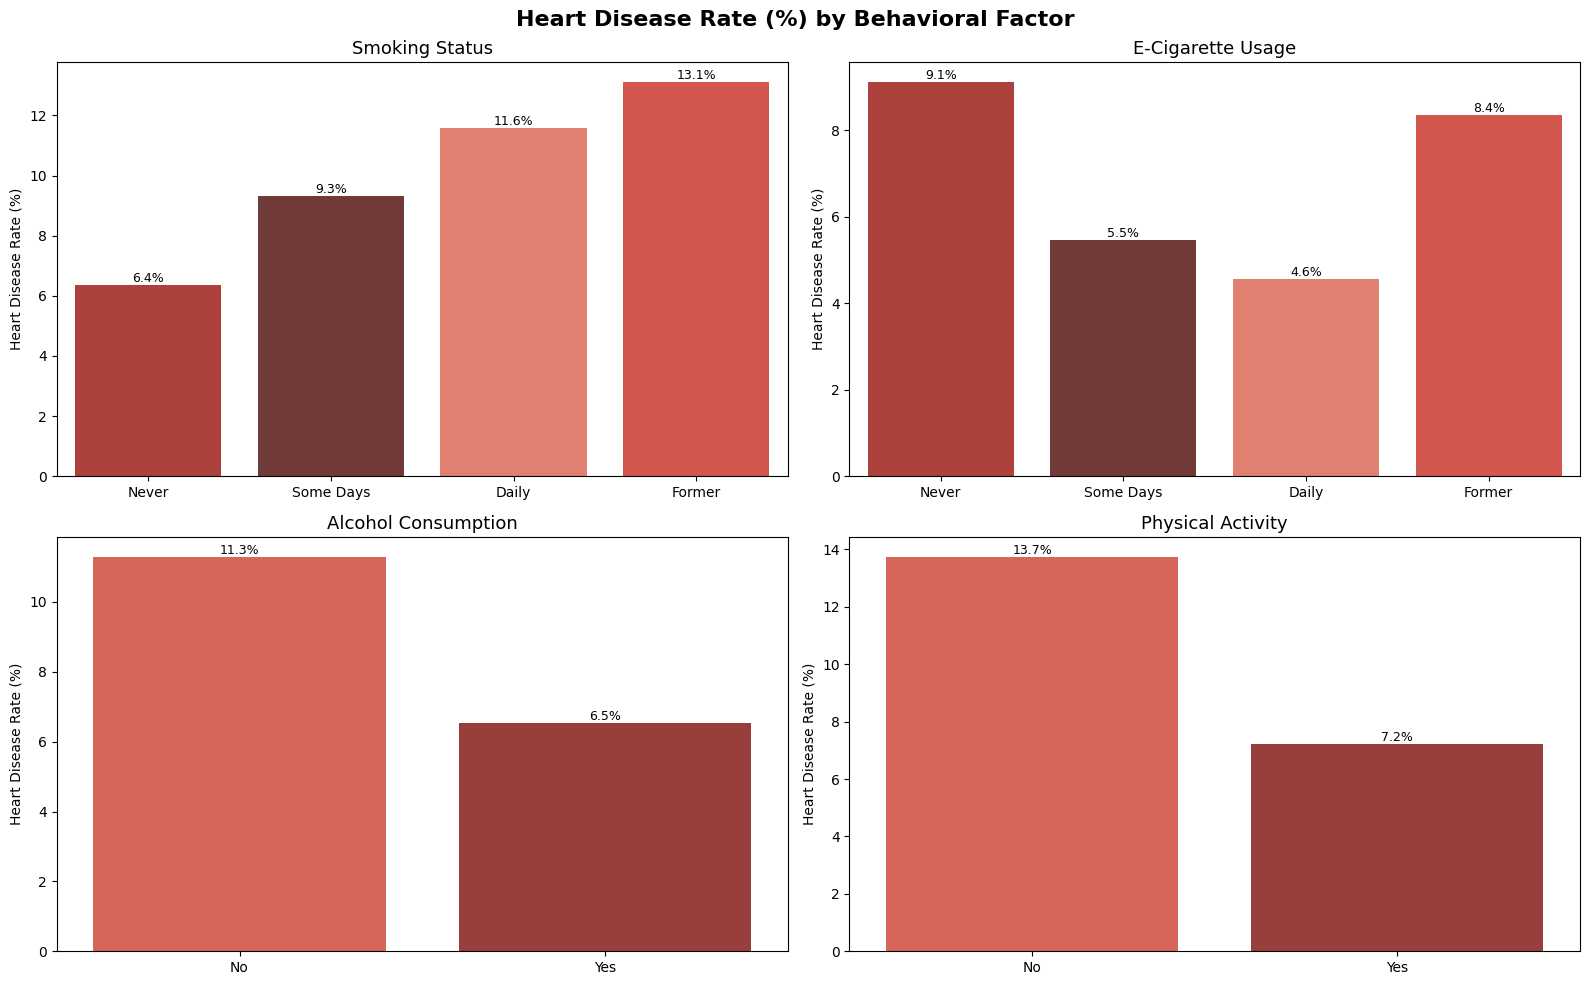

In [135]:
# Suplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Heart Disease Rate (%) by Behavioral Factor', fontsize=16, fontweight='bold')

panels = [
    ('SmokerLabel',        'Smoking Status',      axes[0, 0], smoker_order),
    ('ECigLabel',          'E-Cigarette Usage',   axes[0, 1], ecig_order),
    ('AlcoholDrinkers',    'Alcohol Consumption', axes[1, 0], None),
    ('PhysicalActivities', 'Physical Activity',   axes[1, 1], None)
]

for col, title, ax, order in panels:
    rates = heart_disease_rate(col, lifestyle_df)
    rates.columns = [col, 'HeartDiseaseRate']

    # Bar plot for each
    sns.barplot(data=rates, x=col, y='HeartDiseaseRate', hue=col,
                order=order, palette='Reds_d', ax=ax, legend=False)

    # Labels
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Heart Disease Rate (%)')
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', fontsize=9)

plt.tight_layout()

plt.show()

### **Analysis**

In regard to smokers, former smokers show the highest heart disease rate among the smoking groups with (13.1%). I would think this is most likely because many people only quit smoking perhaps once they've already developed some sort of heart disease symptoms. As for E-cigarette users, it follows a somewhat similar trend, with former vapers having elevated rates. Interestingly, I was suprised to see that alchohol consumption doesn't really show as strong of a correlation to heart disease as alcohol drinkers showed having a lower heart disease rate than non-drinkers, which might be because the survey doesn't real consider or take into account various other potential groupings like light or heavy drinkers for example, but rather just asks a simple yes or no question to the participants. As for physical activity, the chart does suggest that those who are inactive have a higher associativity with developing heart disease.

## **Q2: Prevalance of Factors Among People with Heart Disease**
---
**Question**: Among people who have heart disease, how prevalent is each behavioral/lifestyle factor?

### **Code & Visualizations**

In [136]:
# Filter to only people who have heart disease
heart_patients = lifestyle_df[lifestyle_df['HadHeartDisease'] == 1]

# The percentage of heart disease patients have each behavior
smoker_pct = heart_patients['SmokerLabel'].isin(['Daily', 'Some Days', 'Former']).mean() * 100
ecig_pct = heart_patients['ECigLabel'].isin(['Daily', 'Some Days', 'Former']).mean() * 100
alcohol_pct = (heart_patients['AlcoholDrinkers'] == 'Yes').mean() * 100
inactive_pct = (heart_patients['PhysicalActivities'] == 'No').mean() * 100

prevalence = {
    'Smoking': round(smoker_pct, 1),
    'E-Cigarette Use': round(ecig_pct, 1),
    'Alcohol Consumption': round(alcohol_pct, 1),
    'Physically Inactive': round(inactive_pct, 1)
}

pd.DataFrame(prevalence.items(), columns=['Behavioral Factor', 'Prevalence (%)'])

,Behavioral Factor,Prevalence (%)
0,Smoking,56.1
1,E-Cigarette Use,20.4
2,Alcohol Consumption,39.8
3,Physically Inactive,36.8


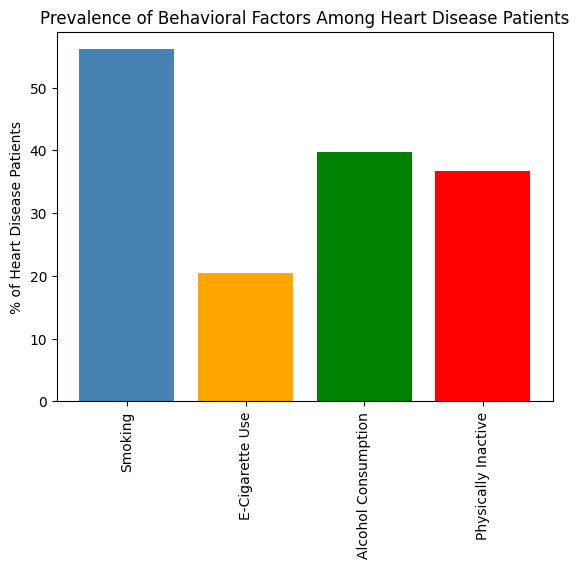

In [137]:
# Bar chart
plt.bar(prevalence.keys(), prevalence.values(), color=['steelblue', 'orange', 'green', 'red'])

# Labels
plt.title('Prevalence of Behavioral Factors Among Heart Disease Patients')
plt.xticks(rotation=90)
plt.ylabel('% of Heart Disease Patients')
plt.show()

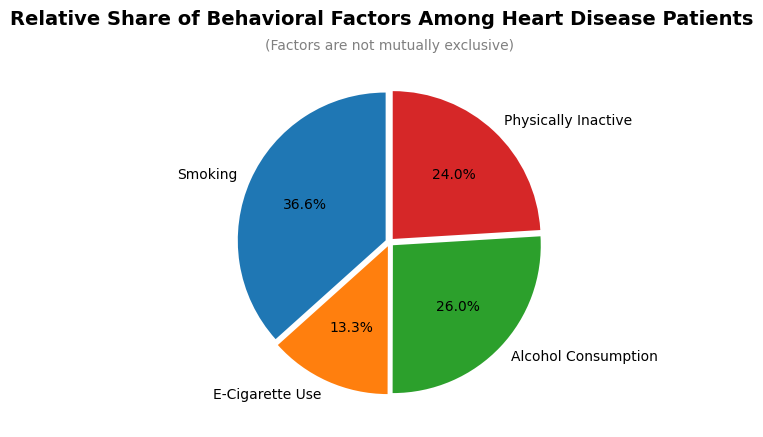

In [138]:
# Pie chart
labels = prevalence.keys()
sizes = prevalence.values()

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        explode=[0.03, 0.03, 0.03, 0.03])

# Labels
plt.suptitle('Relative Share of Behavioral Factors Among Heart Disease Patients',
             fontsize=14, fontweight='bold')
plt.title('(Factors are not mutually exclusive)', fontsize=10, color='gray')

plt.show()

### **Analysis:**

Smoking is by far the most common risk behavior among heart disease patients at 56.1%, with alcohol at 39.8% and physical inactivity at 36.8%. E-cigarette use is the lowest at 20.4%, though that's probably because vaping is still pretty new compared to the others. Since these are measured independently someone can smoke and drink and be inactive all at once so the percentages don't add up to 100%, just as an fyi.

Aside from smoking, which shows the strongest correlation to heart disease, alchohol consumption and being physically inactive and or inactive doesn't show a strong correlation to heart disease (at least within this dataset) as I would have expected. However, this might be because the survey question doesn't really take into consideration asking similar groupings like it does with smoking, so it doesn't really consider heavy drinkers verus like light or casual drinkers for example.

## **Q3: Relationship between Sleep Hours and Heart Disease**
---

**Question:** How does sleep play a factor in heart disease?

### **Code & Visualizations**

In [139]:
# Average sleep for people who have heart disease (1) vs people who don't (0)
lifestyle_df.groupby('HadHeartDisease')['SleepHours'].mean()

,SleepHours
HadHeartDisease,
0,7.018039
1,7.060082


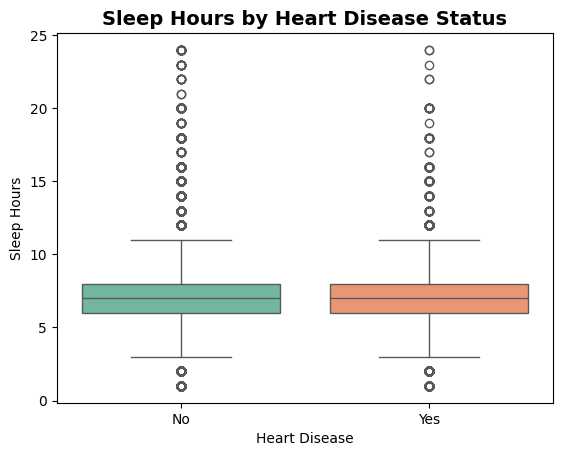

In [147]:
# Boxplot for comparing the sleep between both groups
sns.boxplot( data=lifestyle_df, x='HadHeartDisease', y='SleepHours',
            hue='HadHeartDisease', palette='Set2', legend=False)

# Labels
plt.title('Sleep Hours by Heart Disease Status', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease')
plt.ylabel('Sleep Hours')
plt.xticks([0, 1], ['No', 'Yes'])


plt.show()

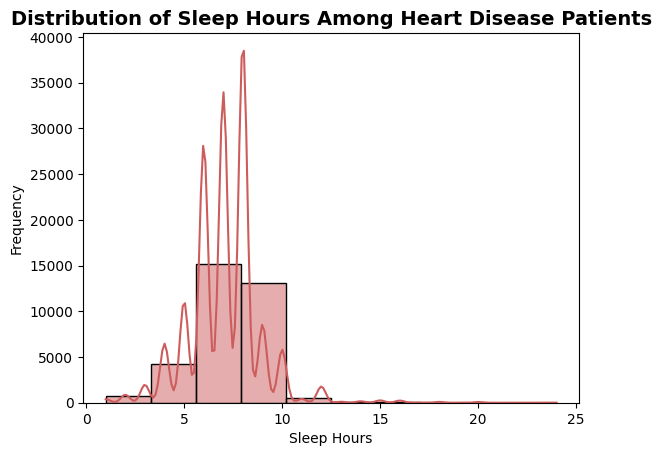

In [141]:
# Sleep distribution among those with heart disease only
heart_sleep = lifestyle_df[lifestyle_df['HadHeartDisease'] == 1]['SleepHours']

sns.histplot(heart_sleep, bins=10, kde=True, color='indianred')

# Labels
plt.title('Distribution of Sleep Hours Among Heart Disease Patients', fontsize=14, fontweight='bold')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')

plt.show()

### **Analysis**

In regards to the average sleep hours for heart diseased people and that of non-heart diseased people, the average number of sleep hours are nearly identical with 7.06 hours and 7.02 hours respectively. The amount of sleep time in a day does not seem to give a considerable contribution to heart disease, but the data suggests that most people with heart disease tend to sleep for about 6 to 8 hours a day.

## **Q4: Heart Disease By State**
---
**Question:** Which states have the highest heart disease rates, and do lifestyle behaviors vary by region?

### **Code & Visualizations**

In [142]:
data['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming', 'Guam', 'Puerto Rico',
       'Virgin Islands'], dtype=object)

In [143]:
# Df for state and heart disease
state_rates = data.groupby('State')['HadHeartDisease'].mean().reset_index()
state_rates.columns = ['State', 'HeartDiseaseRate']

state_rates['HeartDiseaseRate'] = (state_rates['HeartDiseaseRate'] * 100).round(2)

state_rates.head()

,State,HeartDiseaseRate
0,Alabama,12.11
1,Alaska,8.14
2,Arizona,10.07
3,Arkansas,13.35
4,California,6.10


In [144]:
# Mapping the states with their abbreviations (along with some of the other places in the dataset)
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC',
    'Florida': 'FL', 'Georgia': 'GA', 'Guam': 'GU', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY',
    'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA',
    'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Puerto Rico': 'PR', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virgin Islands': 'VI', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

state_rates['Abbrev'] = state_rates['State'].map(state_abbrev)
state_rates = state_rates.dropna(subset=['Abbrev'])

state_rates.sort_values('HeartDiseaseRate', ascending=False).reset_index(drop=True).head(10)

,State,HeartDiseaseRate,Abbrev
0,Arkansas,13.35,AR
1,West Virginia,13.28,WV
2,Alabama,12.11,AL
3,Florida,11.73,FL
4,Oklahoma,11.16,OK
5,Kentucky,10.88,KY
6,Ohio,10.70,OH
7,Maine,10.59,ME
8,Tennessee,10.53,TN
9,New Hampshire,10.39,NH


In [145]:
# Heat map of the states
fig = px.choropleth(
    state_rates,
    locations='Abbrev',
    locationmode='USA-states',
    color='HeartDiseaseRate',
    scope='usa',
    color_continuous_scale='Reds',
    labels={'HeartDiseaseRate': 'Heart Disease Rate (%)'},
    title='Heart Disease Rate by State'
)

fig.update_layout(
    title_x=0.5,
    width=700,
    height=400
)

fig.show()

### **Analysis**

Of the 400,000 people survey in this CDC dataset in 2022, Arkansas had the highest heart disease rate among all the 50 states at 13.35% with West Virginia following closely behind at 13.28%. Among the top states, most were predominently in the south and the appalaction regions, which I found particularly interesting.